# Task 4 — Public Dataset Analysis

## Objective

To comprehend the structure of a public dataset, load and examine it, analyze dataset statistics such as class structure, description length, and image resolution, and explore and display text descriptions together with photos.

### Dataset

Flickr8k is a public image-caption dataset containing photographs paired with natural-language descriptions.

### Analysis Performed

1. Dataset structure and splits
2. Number of images and captions
3. Class structure
4. Caption/description length
5. Word statistics
6. Image resolution
7. Image aspect ratio
8. Image-caption visualization
9. Summary of findings
10. Export of analysis results

In [ ]:
!pip -q install datasets pandas matplotlib pillow

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import os

In [2]:
# Cell 4 — Load Flickr8k efficiently

from datasets import load_dataset

print("Loading Flickr8k dataset...")

dataset = load_dataset(
    "intro/flickr8k",
    trust_remote_code=False
)

print("\n===== Dataset Loaded Successfully =====")
print(dataset)

Loading Flickr8k dataset...


Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]


===== Dataset Loaded Successfully =====
DatasetDict({
    train: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    dev: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [3]:
# Examine the dataset structure

print("===== Dataset Structure =====")
print(dataset)

print("\n===== Dataset Splits =====")

for split in dataset:
    print(f"{split}: {len(dataset[split])} images")

print("\n===== Dataset Features =====")
print(dataset["train"].features)

===== Dataset Structure =====
DatasetDict({
    train: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    dev: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

===== Dataset Splits =====
train: 6000 images
dev: 1000 images
test: 1000 images

===== Dataset Features =====
{'image': Image(mode=None, decode=True), 'split': Value('string'), 'caption_0': Value('string'), 'caption_1': Value('string'), 'caption_2': Value('string'), 'caption_3': Value('string'), 'caption_4': Value('string')}


In [4]:
# Calculate basic dataset statistics

train_count = len(dataset["train"])
dev_count = len(dataset["dev"])
test_count = len(dataset["test"])

total_images = train_count + dev_count + test_count
captions_per_image = 5
total_captions = total_images * captions_per_image

print("===== Dataset Statistics =====")
print(f"Training images    : {train_count}")
print(f"Development images : {dev_count}")
print(f"Test images        : {test_count}")
print(f"Total images       : {total_images}")
print(f"Captions per image : {captions_per_image}")
print(f"Total captions     : {total_captions}")

===== Dataset Statistics =====
Training images    : 6000
Development images : 1000
Test images        : 1000
Total images       : 8000
Captions per image : 5
Total captions     : 40000


## Class Structure

Flickr8k is a public image-caption dataset rather than a classification dataset with predefined semantic class labels.

Therefore, a conventional number of classification classes is not applicable (N/A).

The dataset is organized around images and their associated natural-language captions. These captions provide textual descriptions of the images and make the dataset suitable for image-caption analysis and text-to-image applications.

In [5]:
# Extract all training captions

captions = []

for caption_index in range(5):
    captions.extend(dataset["train"][f"caption_{caption_index}"])

print("===== Caption Collection =====")
print(f"Training captions collected: {len(captions)}")
print("\nExample captions:")

for caption in captions[:5]:
    print("-", caption)

===== Caption Collection =====
Training captions collected: 30000

Example captions:
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A black dog and a spotted dog are fighting
- A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
- A man lays on a bench while his dog sits by him .
- A man in an orange hat starring at something .


In [8]:
# Analyze caption/description length

caption_lengths = [len(caption.split()) for caption in captions]

sorted_lengths = sorted(caption_lengths)
n = len(sorted_lengths)

if n % 2 == 0:
    median_length = (sorted_lengths[n // 2 - 1] + sorted_lengths[n // 2]) / 2
else:
    median_length = sorted_lengths[n // 2]

print("===== Caption Length Analysis =====")
print(f"Number of captions analyzed : {len(captions)}")
print(f"Average caption length      : {sum(caption_lengths) / len(caption_lengths):.2f} words")
print(f"Minimum caption length      : {min(caption_lengths)} words")
print(f"Maximum caption length      : {max(caption_lengths)} words")
print(f"Median caption length       : {median_length:.2f} words")

===== Caption Length Analysis =====
Number of captions analyzed : 30000
Average caption length      : 11.78 words
Minimum caption length      : 2 words
Maximum caption length      : 38 words
Median caption length       : 11.00 words


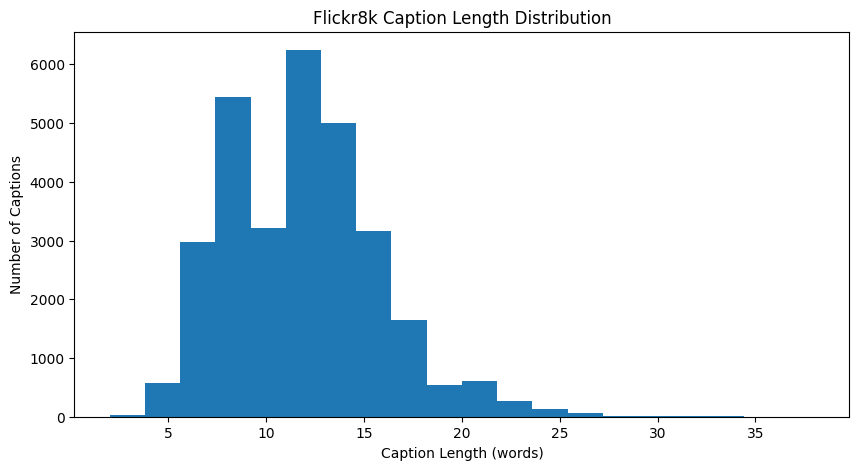

In [10]:
# Visualize caption length distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(caption_lengths, bins=20)

plt.title("Flickr8k Caption Length Distribution")
plt.xlabel("Caption Length (words)")
plt.ylabel("Number of Captions")

plt.show()

In [11]:
# Analyze word frequency

from collections import Counter
import re

all_words = []

for caption in captions:
    words = re.findall(r"\b[a-zA-Z]+\b", caption.lower())
    all_words.extend(words)

word_counts = Counter(all_words)

print("===== Word Statistics =====")
print(f"Total words  : {len(all_words)}")
print(f"Unique words : {len(word_counts)}")

print("\n===== Top 20 Most Frequent Words =====")

for word, count in word_counts.most_common(20):
    print(f"{word:15} {count}")

===== Word Statistics =====
Total words  : 324332
Unique words : 7330

===== Top 20 Most Frequent Words =====
a               46784
in              14094
the             13509
on              8007
is              6907
and             6678
dog             6160
with            5763
man             5383
of              4974
two             4250
white           2932
black           2865
boy             2634
are             2619
woman           2543
girl            2414
to              2306
wearing         2271
at              2102


In [12]:
# Analyze image resolution

widths = []
heights = []

for image in dataset["train"]["image"]:
    widths.append(image.width)
    heights.append(image.height)

print("===== Image Resolution Analysis =====")
print(f"Minimum width  : {min(widths)} pixels")
print(f"Maximum width  : {max(widths)} pixels")
print(f"Average width  : {sum(widths) / len(widths):.2f} pixels")

print(f"Minimum height : {min(heights)} pixels")
print(f"Maximum height : {max(heights)} pixels")
print(f"Average height : {sum(heights) / len(heights):.2f} pixels")

===== Image Resolution Analysis =====
Minimum width  : 164 pixels
Maximum width  : 500 pixels
Average width  : 457.88 pixels
Minimum height : 127 pixels
Maximum height : 500 pixels
Average height : 397.37 pixels


In [13]:
# Analyze image aspect ratios

aspect_ratios = [
    width / height
    for width, height in zip(widths, heights)
]

sorted_ratios = sorted(aspect_ratios)
n = len(sorted_ratios)

if n % 2 == 0:
    median_aspect_ratio = (
        sorted_ratios[n // 2 - 1] + sorted_ratios[n // 2]
    ) / 2
else:
    median_aspect_ratio = sorted_ratios[n // 2]

print("===== Aspect Ratio Analysis =====")
print(f"Minimum aspect ratio : {min(aspect_ratios):.2f}")
print(f"Maximum aspect ratio : {max(aspect_ratios):.2f}")
print(f"Average aspect ratio : {sum(aspect_ratios) / len(aspect_ratios):.2f}")
print(f"Median aspect ratio  : {median_aspect_ratio:.2f}")

===== Aspect Ratio Analysis =====
Minimum aspect ratio : 0.33
Maximum aspect ratio : 3.94
Average aspect ratio : 1.22
Median aspect ratio  : 1.33


Image 1
Caption 1: A child in a pink dress is climbing up a set of stairs in an entry way .
Caption 2: A girl going into a wooden building .
Caption 3: A little girl climbing into a wooden playhouse .
Caption 4: A little girl climbing the stairs to her playhouse .
Caption 5: A little girl in a pink dress going into a wooden cabin .


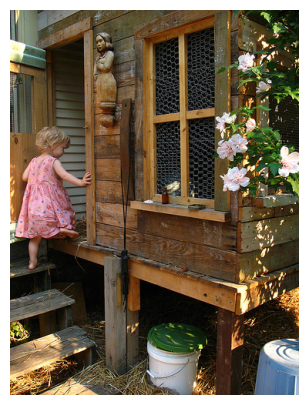

Image 2
Caption 1: A black dog and a spotted dog are fighting
Caption 2: A black dog and a tri-colored dog playing with each other on the road .
Caption 3: A black dog and a white dog with brown spots are staring at each other in the street .
Caption 4: Two dogs of different breeds looking at each other on the road .
Caption 5: Two dogs on pavement moving toward each other .


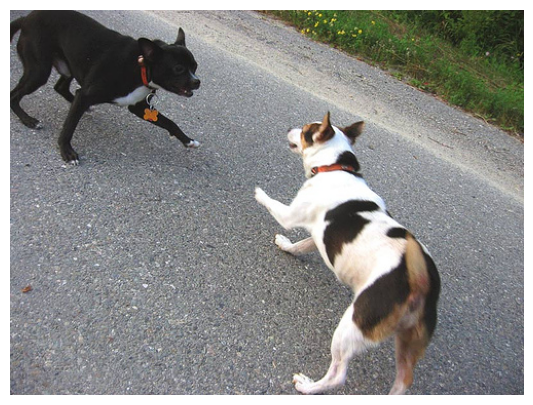

Image 3
Caption 1: A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
Caption 2: A little girl is sitting in front of a large painted rainbow .
Caption 3: A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
Caption 4: There is a girl with pigtails sitting in front of a rainbow painting .
Caption 5: Young girl with pigtails painting outside in the grass .


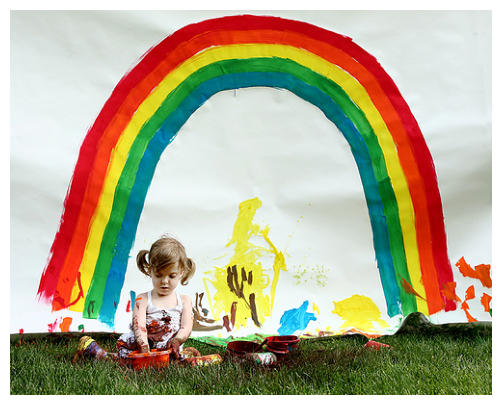

Image 4
Caption 1: A man lays on a bench while his dog sits by him .
Caption 2: A man lays on the bench to which a white dog is also tied .
Caption 3: a man sleeping on a bench outside with a white and black dog sitting next to him .
Caption 4: A shirtless man lies on a park bench with his dog .
Caption 5: man laying on bench holding leash of dog sitting on ground


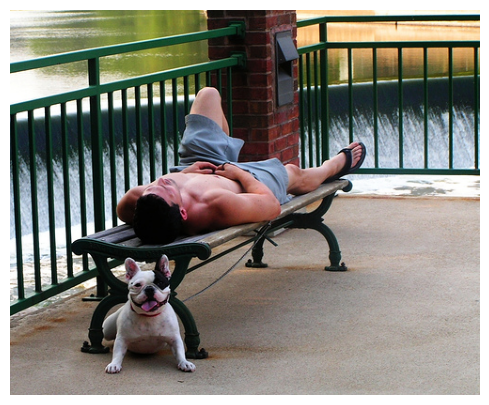

In [14]:
# Display sample images with their text descriptions

import matplotlib.pyplot as plt

sample_indices = [0, 1, 2, 3]

for index in sample_indices:

    image = dataset["train"][index]["image"]

    print("=" * 80)
    print(f"Image {index + 1}")

    for caption_index in range(5):
        caption = dataset["train"][index][f"caption_{caption_index}"]
        print(f"Caption {caption_index + 1}: {caption}")

    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [16]:
# Create a complete analysis summary

import pandas as pd

sorted_lengths = sorted(caption_lengths)
n = len(sorted_lengths)

if n % 2 == 0:
    median_caption_length = (
        sorted_lengths[n // 2 - 1] + sorted_lengths[n // 2]
    ) / 2
else:
    median_caption_length = sorted_lengths[n // 2]

analysis_summary = {
    "Training images": train_count,
    "Development images": dev_count,
    "Test images": test_count,
    "Total images": total_images,
    "Captions per image": captions_per_image,
    "Total captions": total_captions,
    "Average caption length": round(sum(caption_lengths) / len(caption_lengths), 2),
    "Minimum caption length": min(caption_lengths),
    "Maximum caption length": max(caption_lengths),
    "Median caption length": round(median_caption_length, 2),
    "Total words": len(all_words),
    "Unique words": len(word_counts),
    "Minimum image width": min(widths),
    "Maximum image width": max(widths),
    "Average image width": round(sum(widths) / len(widths), 2),
    "Minimum image height": min(heights),
    "Maximum image height": max(heights),
    "Average image height": round(sum(heights) / len(heights), 2),
    "Minimum aspect ratio": round(min(aspect_ratios), 2),
    "Maximum aspect ratio": round(max(aspect_ratios), 2),
    "Average aspect ratio": round(sum(aspect_ratios) / len(aspect_ratios), 2),
    "Median aspect ratio": round(median_aspect_ratio, 2),
    "Classification classes": "N/A - image-caption dataset"
}

summary_df = pd.DataFrame(
    list(analysis_summary.items()),
    columns=["Metric", "Value"]
)

print("===== Analysis Summary =====")
display(summary_df)

===== Analysis Summary =====


,Metric,Value
0,Training images,6000
1,Development images,1000
2,Test images,1000
3,Total images,8000
4,Captions per image,5
5,Total captions,40000
6,Average caption length,11.78
7,Minimum caption length,2
8,Maximum caption length,38
9,Median caption length,11.0


In [17]:
# Save the analysis summary as a CSV file

import os

os.makedirs("outputs/graphs", exist_ok=True)

output_path = "outputs/graphs/flickr8k_analysis_results.csv"

summary_df.to_csv(output_path, index=False)

print("Analysis results saved successfully to:")
print(output_path)

Analysis results saved successfully to:
outputs/graphs/flickr8k_analysis_results.csv


# Task 4 Findings

## Public Dataset

The Flickr8k dataset was loaded and examined as a public image-caption dataset.

## Dataset Structure

The dataset contains training, development, and test splits. Each image is associated with five natural-language captions.

## Class Structure

Flickr8k is not organized as a conventional classification dataset with predefined semantic class labels. Therefore, the number of classification classes is not applicable (N/A).

## Description Length

Caption lengths were analyzed using the number of words in each caption. Minimum, maximum, average, and median caption lengths were calculated.

## Vocabulary

Word-frequency analysis was performed to examine the vocabulary used in the image descriptions.

## Image Resolution

Image width and height were analyzed to understand the resolution characteristics of the dataset.

## Aspect Ratio

Image aspect ratios were calculated to understand the visual dimensions of the photographs.

## Image and Text Exploration

Sample photographs were displayed together with their five associated natural-language descriptions.

## Conclusion

The analysis provides an understanding of the structure, textual descriptions, image dimensions, and image-caption relationships in Flickr8k. These characteristics are useful for subsequent text preprocessing, text embedding, and text-to-image modeling tasks in this project.

In [18]:
# Final verification of Task 4

verification = {
    "Dataset loaded": "dataset" in globals(),
    "Train split available": "train" in dataset,
    "Caption analysis completed": len(captions) > 0,
    "Caption length analysis completed": len(caption_lengths) > 0,
    "Word analysis completed": len(word_counts) > 0,
    "Image resolution analysis completed": len(widths) > 0 and len(heights) > 0,
    "Aspect ratio analysis completed": len(aspect_ratios) > 0,
    "Image-caption visualization completed": True,
    "Analysis summary created": "summary_df" in globals(),
    "CSV output exists": os.path.exists(output_path)
}

print("===== TASK 4 FINAL VERIFICATION =====")

for check, result in verification.items():
    status = "PASS" if result else "FAIL"
    print(f"{status} - {check}")

print("\n===== FINAL RESULT =====")

if all(verification.values()):
    print("TASK 4 COMPLETED SUCCESSFULLY")
else:
    print("TASK 4 REQUIRES ATTENTION")

===== TASK 4 FINAL VERIFICATION =====
PASS - Dataset loaded
PASS - Train split available
PASS - Caption analysis completed
PASS - Caption length analysis completed
PASS - Word analysis completed
PASS - Image resolution analysis completed
PASS - Aspect ratio analysis completed
PASS - Image-caption visualization completed
PASS - Analysis summary created
PASS - CSV output exists

===== FINAL RESULT =====
TASK 4 COMPLETED SUCCESSFULLY
